# Employee Layoff Risk Prediction Using Deep Learning Artificial Neural Networks (ANN)

## Problem Statement:The objective of this project is to build a multiclass classification model that predicts an employee's Layoff_Risk based on demographic information, job characteristics, AI adoption, automation exposure, education, and workplace attributes. The model helps identify employees with different levels of layoff risk to support workforce planning and reskilling initiatives.

In [5]:
import pandas as pd
import numpy as np
ai_impact_layoff_risk_data=pd.read_csv("C:/Users/abrau/ML Projects/Python IVY Feb-2024-20260611T164017Z-3-001/Python IVY Feb-2024/My ML Projects/Classification Projects/AI impact on Layoff Deep Learning by ANN/ai-impact-jobs-layoff-risk-dataset.csv",
                            encoding='latin')
print('Data Before deleting duplicate values:',ai_impact_layoff_risk_data.shape)  
ai_impact_layoff_risk_data.drop_duplicates(inplace=True)
print('Data After:deleting duplicate values',ai_impact_layoff_risk_data.shape)
pd.set_option('display.max_rows',None) 
pd.set_option('display.max_columns',None)  
ai_impact_layoff_risk_data.head(10)

Data Before deleting duplicate values: (20000, 16)
Data After:deleting duplicate values (20000, 16)


,Age,Education_Level,Years_of_Experience,Industry,Job_Role,Company_Size,Job_Level,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,AI_Adoption_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours,Layoff_Risk
0,59,Master's,6,Finance,Accountant,Medium,Entry,84,21,94,Medium,5,7,40,26,High
1,44,Master's,14,Manufacturing,Production Supervisor,Small,Entry,30,84,68,Low,2,2,14,9,Low
2,36,Bachelor's,7,Retail,Store Manager,Medium,Senior,12,86,71,Low,0,1,6,3,Low
3,27,Bachelor's,6,Finance,Auditor,Large,Entry,90,18,21,Medium,3,10,67,26,High
4,49,High School,12,Finance,Auditor,Small,Entry,49,52,72,Medium,5,13,26,19,Medium
5,45,PhD,9,Telecom,Network Engineer,Large,Entry,72,33,54,Medium,4,5,69,9,High
6,48,Bachelor's,10,IT,Software Engineer,Small,Entry,46,63,63,Medium,2,7,45,9,Medium
7,23,Master's,2,Retail,Store Manager,Medium,Mid,36,37,77,Low,2,0,27,3,Medium
8,24,Bachelor's,3,IT,ML Engineer,Large,Entry,41,62,90,Low,1,1,20,8,Low
9,48,Master's,6,Retail,Inventory Analyst,Small,Senior,84,8,81,Medium,2,5,67,29,Medium


### Target Variable:Layoff_Risk

## Exploratory Data Analysis

<Axes: xlabel='Layoff_Risk'>

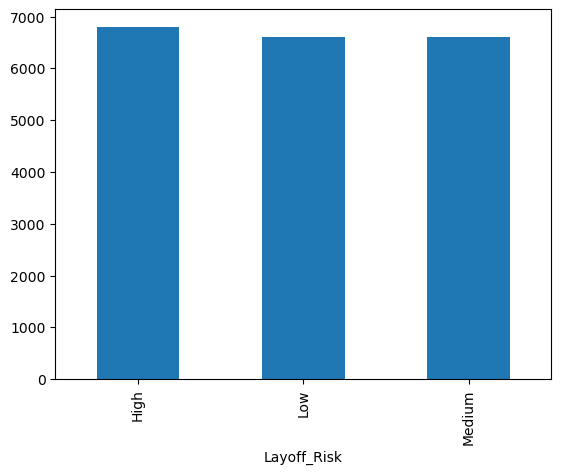

In [6]:
ai_impact_layoff_risk_data.groupby('Layoff_Risk').size().plot(kind='bar')

In [7]:
ai_impact_layoff_risk_data.columns

Index(['Age', 'Education_Level', 'Years_of_Experience', 'Industry', 'Job_Role',
       'Company_Size', 'Job_Level', 'Routine_Task_Percentage',
       'Creativity_Requirement', 'Human_Interaction_Level',
       'AI_Adoption_Level', 'Number_of_AI_Tools_Used',
       'AI_Usage_Hours_Per_Week', 'Tasks_Automated_Percentage',
       'AI_Training_Hours', 'Layoff_Risk'],
      dtype='object')

In [8]:
ai_impact_layoff_risk_data.nunique()

Age                            40
Education_Level                 4
Years_of_Experience            27
Industry                        8
Job_Role                       24
Company_Size                    3
Job_Level                       3
Routine_Task_Percentage        85
Creativity_Requirement        101
Human_Interaction_Level        80
AI_Adoption_Level               3
Number_of_AI_Tools_Used        11
AI_Usage_Hours_Per_Week        31
Tasks_Automated_Percentage     90
AI_Training_Hours              80
Layoff_Risk                     3
dtype: int64

In [9]:
ai_impact_layoff_risk_data.columns

Index(['Age', 'Education_Level', 'Years_of_Experience', 'Industry', 'Job_Role',
       'Company_Size', 'Job_Level', 'Routine_Task_Percentage',
       'Creativity_Requirement', 'Human_Interaction_Level',
       'AI_Adoption_Level', 'Number_of_AI_Tools_Used',
       'AI_Usage_Hours_Per_Week', 'Tasks_Automated_Percentage',
       'AI_Training_Hours', 'Layoff_Risk'],
      dtype='object')

### CategoricalCols=['Education_Level','Industry','Job_Role','Company_Size', 'Job_Level','AI_Adoption_Level', 'Layoff_Risk']
### ContinousCols=['Age','Years_of_Experience','Routine_Task_Percentage','Creativity_Requirement', 'Human_Interaction_Level''AI_Usage_Hours_Per_Week', 'Tasks_Automated_Percentage','AI_Training_Hours'] 

In [10]:
ai_impact_layoff_risk_data.shape

(20000, 16)

In [11]:
ai_impact_layoff_risk_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Age                         20000 non-null  int64 
 1   Education_Level             20000 non-null  object
 2   Years_of_Experience         20000 non-null  int64 
 3   Industry                    20000 non-null  object
 4   Job_Role                    20000 non-null  object
 5   Company_Size                20000 non-null  object
 6   Job_Level                   20000 non-null  object
 7   Routine_Task_Percentage     20000 non-null  int64 
 8   Creativity_Requirement      20000 non-null  int64 
 9   Human_Interaction_Level     20000 non-null  int64 
 10  AI_Adoption_Level           20000 non-null  object
 11  Number_of_AI_Tools_Used     20000 non-null  int64 
 12  AI_Usage_Hours_Per_Week     20000 non-null  int64 
 13  Tasks_Automated_Percentage  20000 non-null  in

In [12]:
ai_impact_layoff_risk_data.describe()

,Age,Years_of_Experience,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.00000,20000.000000
mean,40.361500,7.265500,51.885500,47.786700,60.055000,2.460350,6.77395,37.22895,12.621400
std,11.526333,4.720606,24.437808,26.100482,22.267801,2.097486,6.08637,19.99512,13.552647
min,21.000000,0.000000,10.000000,0.000000,20.000000,0.000000,0.00000,4.00000,0.000000
25%,30.000000,4.000000,31.000000,27.000000,41.000000,1.000000,2.00000,21.00000,4.000000
50%,40.000000,7.000000,52.000000,48.000000,62.000000,2.000000,5.00000,35.00000,8.000000
75%,50.000000,11.000000,73.000000,69.000000,79.000000,4.000000,10.00000,51.00000,18.000000
max,60.000000,32.000000,94.000000,100.000000,99.000000,10.000000,30.00000,93.00000,79.000000


## Uni Variate Analysis by Bar Charts

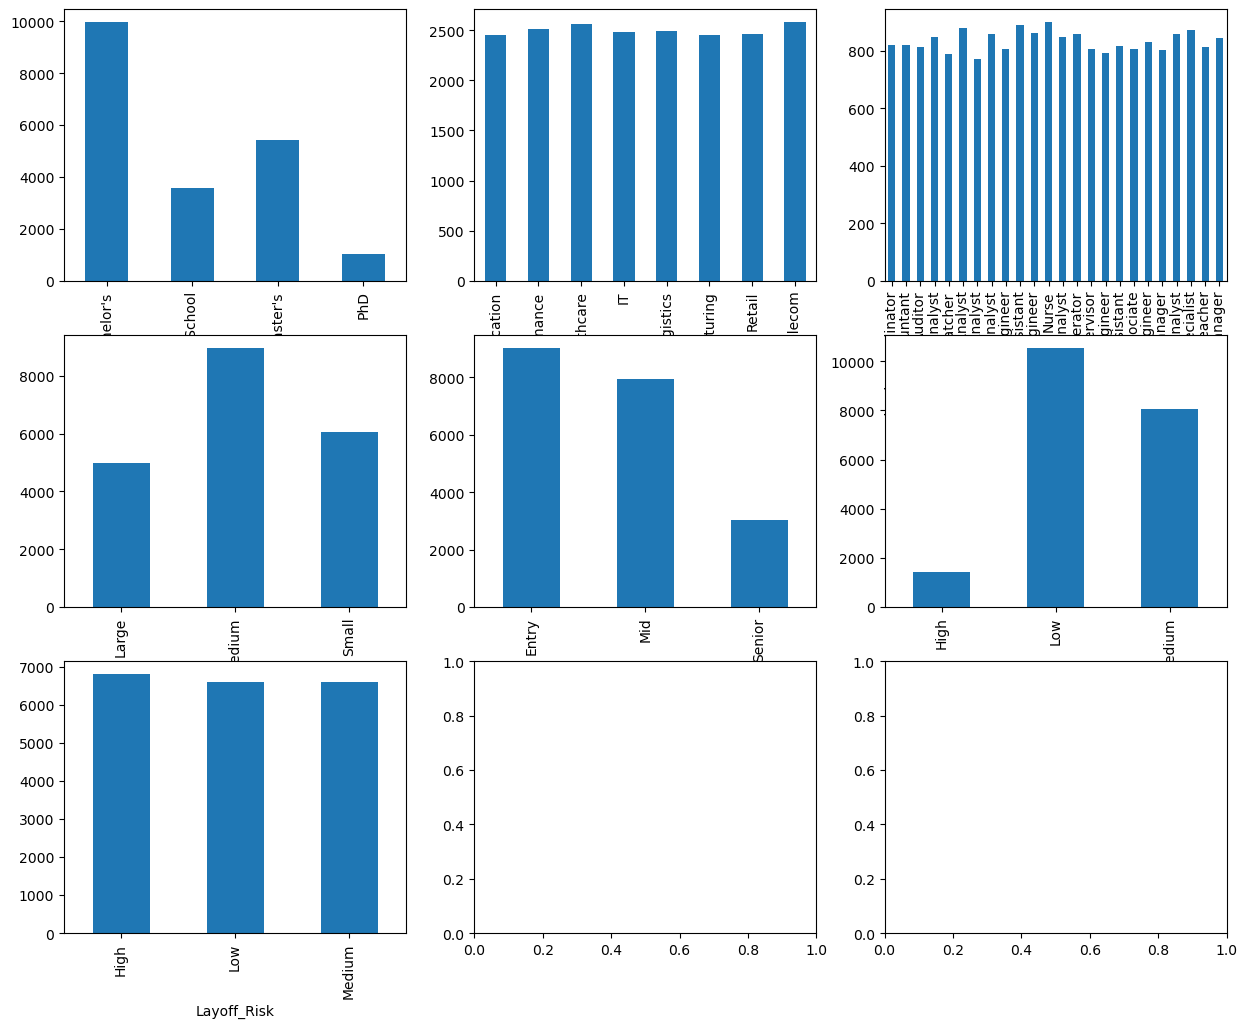

In [13]:
CategoricalCols=['Education_Level','Industry','Job_Role','Company_Size', 'Job_Level','AI_Adoption_Level', 'Layoff_Risk']
import matplotlib.pyplot as plt
fig,subplots=plt.subplots(3,3,figsize=(15,12))
subplots=subplots.flatten()
for cols, no_of_columns in zip(CategoricalCols,range(len(CategoricalCols))):
    ai_impact_layoff_risk_data.groupby(cols).size().plot(kind='bar',ax=subplots[no_of_columns])

### No need of imbalance treatment

## Uni Variate Analysis by Histogram

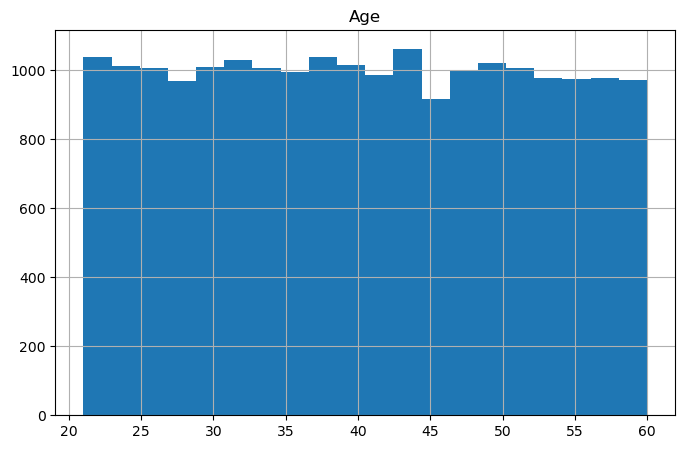

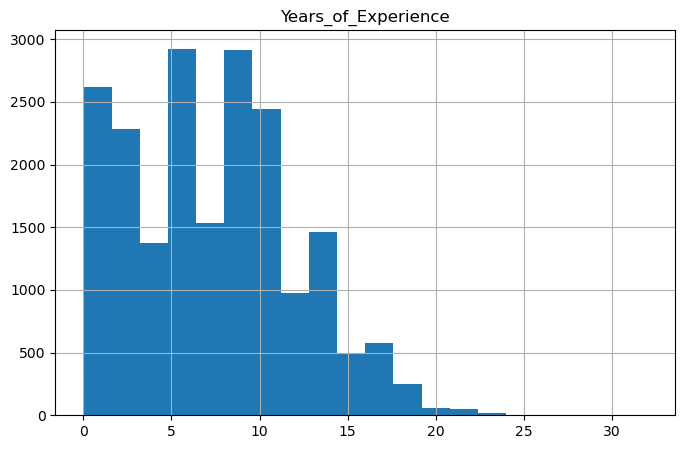

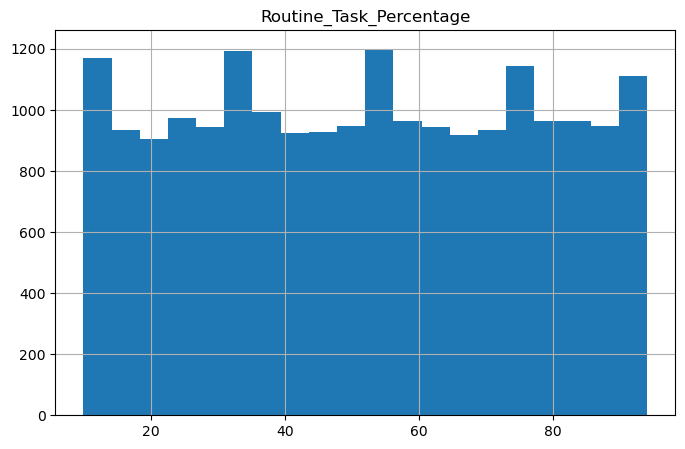

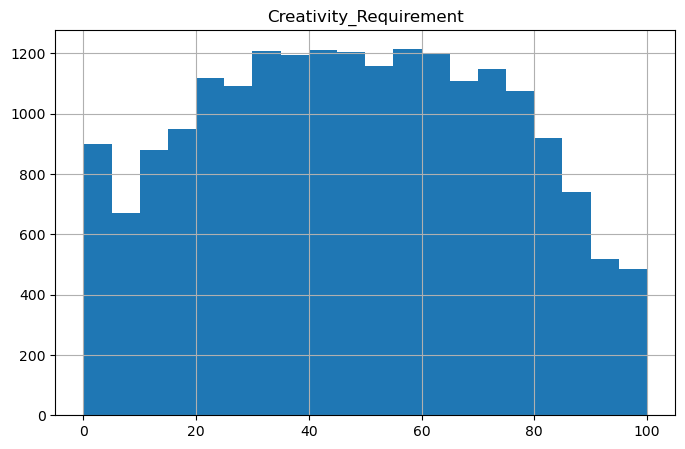

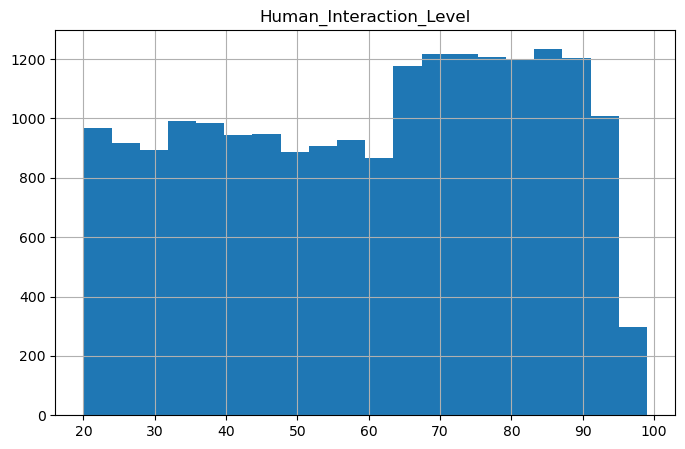

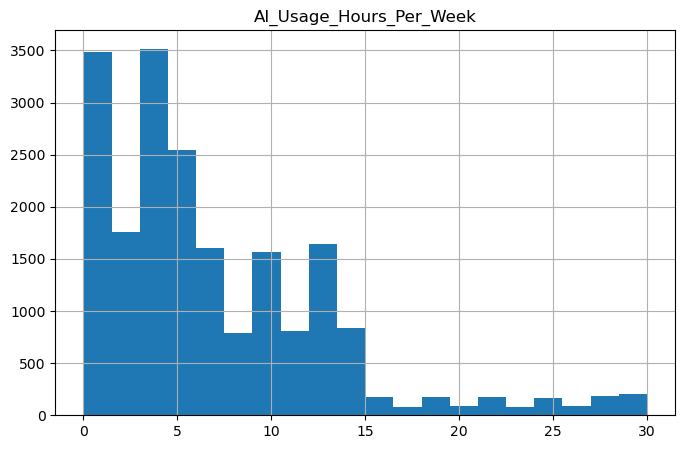

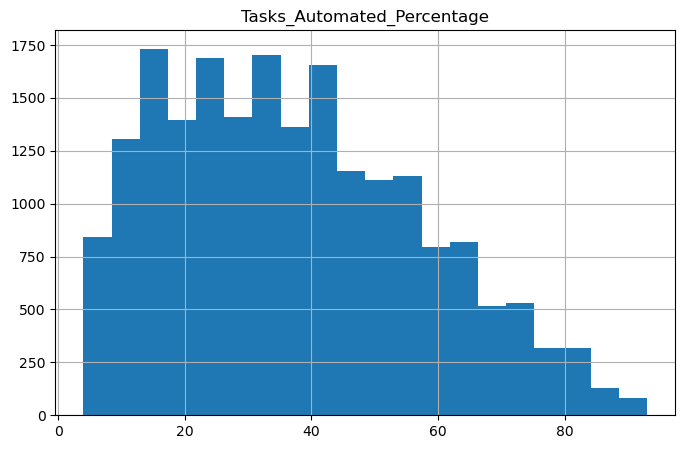

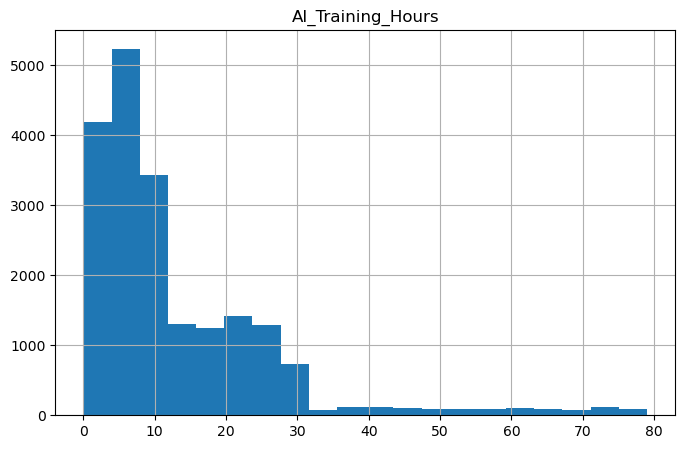

In [14]:
ContinousCols=['Age','Years_of_Experience','Routine_Task_Percentage','Creativity_Requirement', 'Human_Interaction_Level','AI_Usage_Hours_Per_Week', 'Tasks_Automated_Percentage','AI_Training_Hours']
for cols in ContinousCols:
    ai_impact_layoff_risk_data.hist(cols,bins=20,figsize=(8,5))

### No need of Outlier Treatment

### No need of missing value treatment

In [15]:
ai_impact_layoff_risk_data.isnull().sum()

Age                           0
Education_Level               0
Years_of_Experience           0
Industry                      0
Job_Role                      0
Company_Size                  0
Job_Level                     0
Routine_Task_Percentage       0
Creativity_Requirement        0
Human_Interaction_Level       0
AI_Adoption_Level             0
Number_of_AI_Tools_Used       0
AI_Usage_Hours_Per_Week       0
Tasks_Automated_Percentage    0
AI_Training_Hours             0
Layoff_Risk                   0
dtype: int64

## Continous Vs Categorical Bivariate Analysis by Box Plots

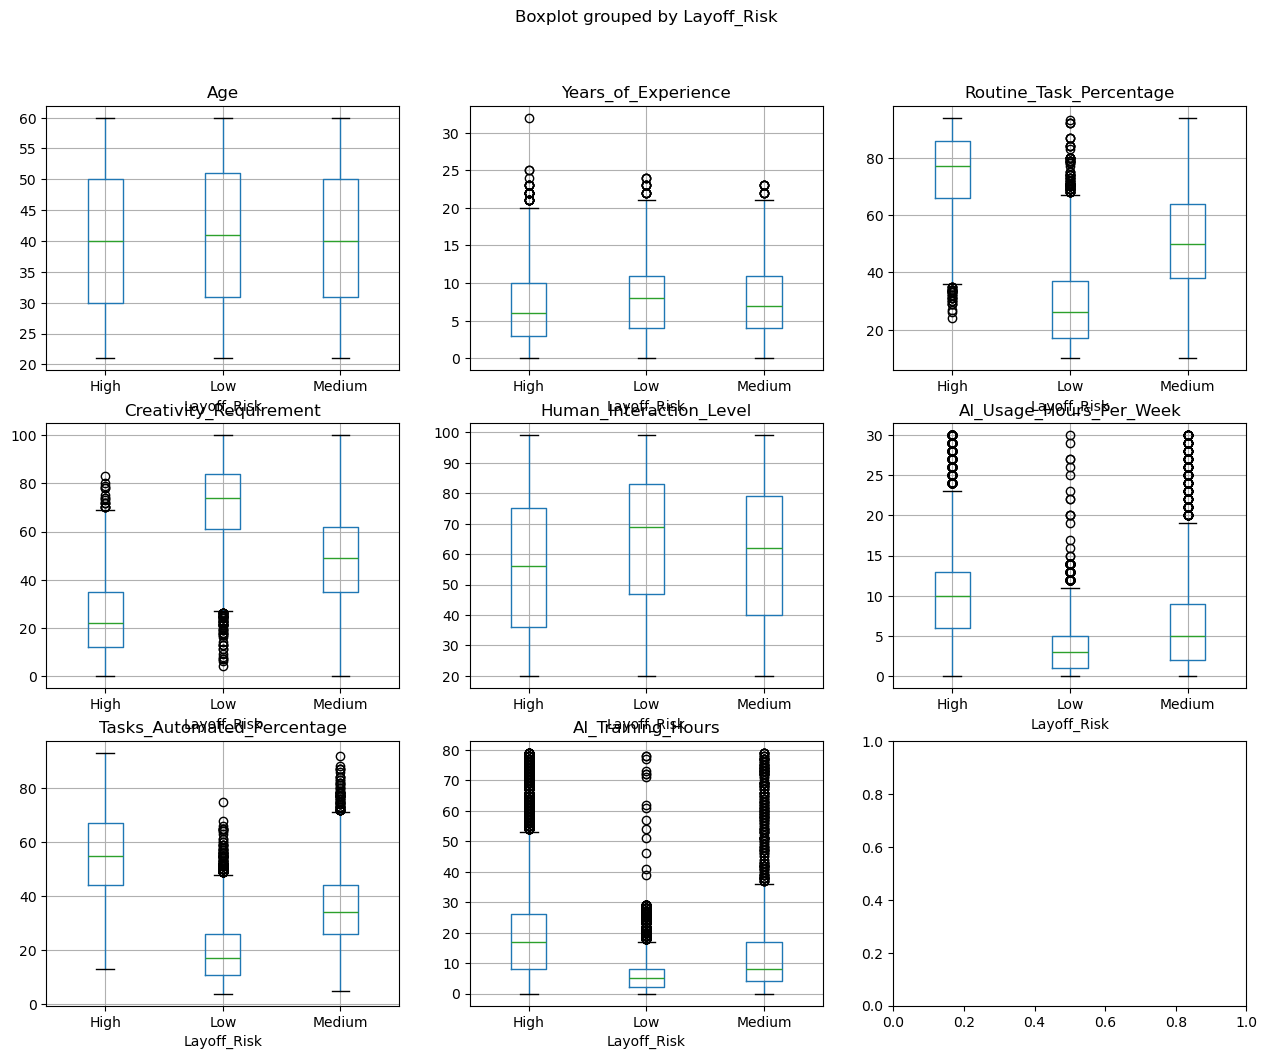

In [16]:
ContinousCols=['Age','Years_of_Experience','Routine_Task_Percentage','Creativity_Requirement', 'Human_Interaction_Level','AI_Usage_Hours_Per_Week', 'Tasks_Automated_Percentage','AI_Training_Hours']
import matplotlib.pyplot as plt
fig,subplots=plt.subplots(3,3,figsize=(15,12))
subplots=subplots.flatten()
for cols, no_of_cols in zip(ContinousCols,range(len(ContinousCols))):
    ai_impact_layoff_risk_data.boxplot(column=cols,by='Layoff_Risk',vert=True,ax=subplots[no_of_cols])


## Statistical Feature Selection by Anova Function

In [18]:
ContinousCols=['Age','Years_of_Experience','Routine_Task_Percentage','Creativity_Requirement', 'Human_Interaction_Level','AI_Usage_Hours_Per_Week', 'Tasks_Automated_Percentage','AI_Training_Hours']
SelectedPredictors=[]
from scipy.stats import f_oneway

for cols in ContinousCols:
    CategoricalGroupLists=ai_impact_layoff_risk_data.groupby('Layoff_Risk')[cols].apply(list)
    AnovaResults=f_oneway(*CategoricalGroupLists)
    if AnovaResults[1]<0.05: 
        print(cols,' is corelated with Layoff_Risk and P values is:',AnovaResults[1])
        SelectedPredictors.append(cols)
    else:
        print(cols,' is not corelated with Layoff_Risk and P values is:',AnovaResults[1])
print(SelectedPredictors)
        
        

Age  is corelated with Layoff_Risk and P values is: 1.2292684860429205e-06
Years_of_Experience  is corelated with Layoff_Risk and P values is: 6.630873660286188e-45
Routine_Task_Percentage  is corelated with Layoff_Risk and P values is: 0.0
Creativity_Requirement  is corelated with Layoff_Risk and P values is: 0.0
Human_Interaction_Level  is corelated with Layoff_Risk and P values is: 1.0037753365653694e-113
AI_Usage_Hours_Per_Week  is corelated with Layoff_Risk and P values is: 0.0
Tasks_Automated_Percentage  is corelated with Layoff_Risk and P values is: 0.0
AI_Training_Hours  is corelated with Layoff_Risk and P values is: 0.0
['Age', 'Years_of_Experience', 'Routine_Task_Percentage', 'Creativity_Requirement', 'Human_Interaction_Level', 'AI_Usage_Hours_Per_Week', 'Tasks_Automated_Percentage', 'AI_Training_Hours']


## Categorical Vs Categorical Bivariate Analysis by Grouped Bar Charts

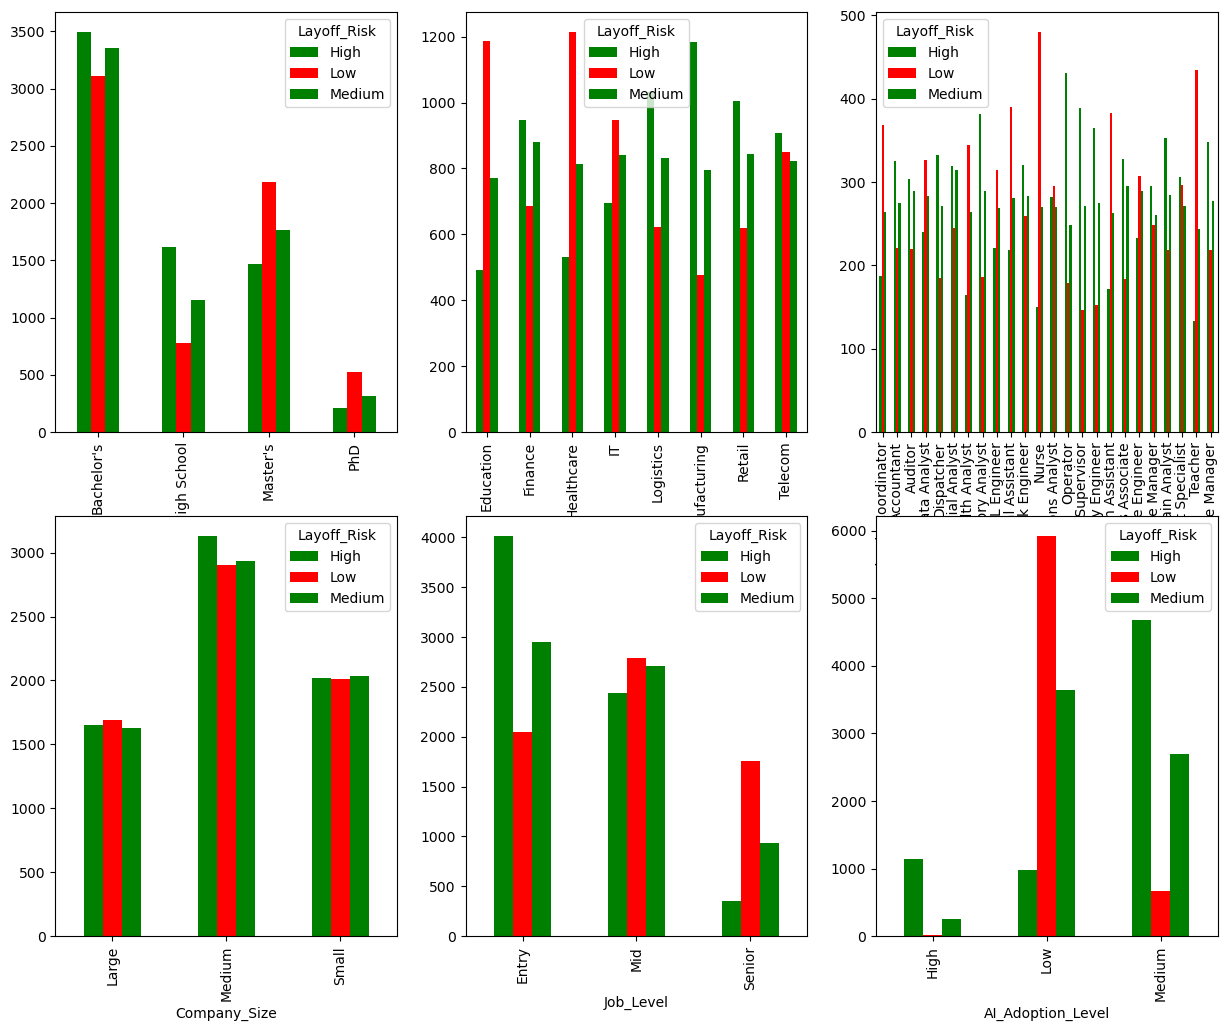

In [19]:
CategoricalCols=['Education_Level','Industry','Job_Role','Company_Size', 'Job_Level','AI_Adoption_Level']

import matplotlib.pyplot as plt
fig,subplots=plt.subplots(2,3,figsize=(15,12))
subplots=subplots.flatten()
for cols, no_of_cols in zip(CategoricalCols,range(len(CategoricalCols))):
    crosstabresults=pd.crosstab(columns=ai_impact_layoff_risk_data['Layoff_Risk'],index=ai_impact_layoff_risk_data[cols])
    crosstabresults.plot.bar(color=['green','red'],ax=subplots[no_of_cols])


## Statistical Feature Selection by Chi2 Function

In [21]:
CategoricalCols=['Education_Level','Industry','Job_Role','Company_Size', 'Job_Level','AI_Adoption_Level']
SelectedPredictors=[]
from  scipy.stats  import chi2_contingency
for  cols in CategoricalCols:
    crosstabresults=pd.crosstab(columns=ai_impact_layoff_risk_data['Layoff_Risk'],index=ai_impact_layoff_risk_data[cols]) 
    chi2_results=chi2_contingency(crosstabresults) 
    if chi2_results[1]<0.05:
        print(cols,' is correlated with Layoff_Risk and p value is:',chi2_results[1])
        SelectedPredictors.append(cols)
    else:
        print(cols,' is not correlated with Layoff_Risk and p value is:',chi2_results[1])
SelectedPredictors

Education_Level  is correlated with Layoff_Risk and p value is: 3.1088973146061364e-126
Industry  is correlated with Layoff_Risk and p value is: 1.7918215338971803e-237
Job_Role  is correlated with Layoff_Risk and p value is: 1.3708157204141478e-228
Company_Size  is not correlated with Layoff_Risk and p value is: 0.09614670901055021
Job_Level  is correlated with Layoff_Risk and p value is: 0.0
AI_Adoption_Level  is correlated with Layoff_Risk and p value is: 0.0


['Education_Level', 'Industry', 'Job_Role', 'Job_Level', 'AI_Adoption_Level']

## Selecting final predictors for Machine Learning

In [4]:
ai_impact_layoff_risk_data.columns

Index(['Age', 'Education_Level', 'Years_of_Experience', 'Industry', 'Job_Role',
       'Company_Size', 'Job_Level', 'Routine_Task_Percentage',
       'Creativity_Requirement', 'Human_Interaction_Level',
       'AI_Adoption_Level', 'Number_of_AI_Tools_Used',
       'AI_Usage_Hours_Per_Week', 'Tasks_Automated_Percentage',
       'AI_Training_Hours', 'Layoff_Risk'],
      dtype='object')

In [40]:
SelectedColumns=['Age', 'Education_Level', 'Years_of_Experience', 'Industry', 'Job_Role',
       'Company_Size', 'Job_Level', 'Routine_Task_Percentage',
       'Creativity_Requirement', 'Human_Interaction_Level',
       'AI_Adoption_Level', 'Number_of_AI_Tools_Used',
       'AI_Usage_Hours_Per_Week', 'Tasks_Automated_Percentage',
       'AI_Training_Hours']


DataForML_ai_impact_layoff_risk_data=ai_impact_layoff_risk_data[SelectedColumns] 
DataForML_ai_impact_layoff_risk_data.to_pickle('DataForML_ai_impact_layoff_risk_data.pkl')
DataForML_ai_impact_layoff_risk_data=pd.read_pickle('DataForML_ai_impact_layoff_risk_data.pkl')

## Data Pre-processing for Machine Learning
## Converting the nominal variable to numeric using get_dummies()

In [41]:
DataForML_ai_impact_layoff_risk_data=pd.get_dummies(DataForML_ai_impact_layoff_risk_data)
DataForML_ai_impact_layoff_risk_data.head()

,Age,Years_of_Experience,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours,Education_Level_Bachelor's,Education_Level_High School,Education_Level_Master's,Education_Level_PhD,Industry_Education,Industry_Finance,Industry_Healthcare,Industry_IT,Industry_Logistics,Industry_Manufacturing,Industry_Retail,Industry_Telecom,Job_Role_Academic Coordinator,Job_Role_Accountant,Job_Role_Auditor,Job_Role_Data Analyst,Job_Role_Dispatcher,Job_Role_Financial Analyst,Job_Role_Health Analyst,Job_Role_Inventory Analyst,Job_Role_ML Engineer,Job_Role_Medical Assistant,Job_Role_Network Engineer,Job_Role_Nurse,Job_Role_Operations Analyst,Job_Role_Operator,Job_Role_Production Supervisor,Job_Role_Quality Engineer,Job_Role_Research Assistant,Job_Role_Sales Associate,Job_Role_Software Engineer,Job_Role_Store Manager,Job_Role_Supply Chain Analyst,Job_Role_Support Specialist,Job_Role_Teacher,Job_Role_Warehouse Manager,Company_Size_Large,Company_Size_Medium,Company_Size_Small,Job_Level_Entry,Job_Level_Mid,Job_Level_Senior,AI_Adoption_Level_High,AI_Adoption_Level_Low,AI_Adoption_Level_Medium
0,59,6,84,21,94,5,7,40,26,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,True
1,44,14,30,84,68,2,2,14,9,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,True,False
2,36,7,12,86,71,0,1,6,3,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,True,False
3,27,6,90,18,21,3,10,67,26,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True
4,49,12,49,52,72,5,13,26,19,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,True


## Converting the binary nominal variable to numeric using 1/0 mapping

In [42]:
DataForML_ai_impact_layoff_risk_data.replace({False:0,True:1},inplace=True)

C:\Users\abrau\AppData\Local\Temp\ipykernel_30556\1895340707.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  DataForML_ai_impact_layoff_risk_data.replace({False:0,True:1},inplace=True)


In [25]:
DataForML_ai_impact_layoff_risk_data.columns

Index(['Age', 'Years_of_Experience', 'Routine_Task_Percentage',
       'Creativity_Requirement', 'Human_Interaction_Level',
       'Number_of_AI_Tools_Used', 'AI_Usage_Hours_Per_Week',
       'Tasks_Automated_Percentage', 'AI_Training_Hours',
       'Education_Level_Bachelor's', 'Education_Level_High School',
       'Education_Level_Master's', 'Education_Level_PhD', 'Industry_Education',
       'Industry_Finance', 'Industry_Healthcare', 'Industry_IT',
       'Industry_Logistics', 'Industry_Manufacturing', 'Industry_Retail',
       'Industry_Telecom', 'Job_Role_Academic Coordinator',
       'Job_Role_Accountant', 'Job_Role_Auditor', 'Job_Role_Data Analyst',
       'Job_Role_Dispatcher', 'Job_Role_Financial Analyst',
       'Job_Role_Health Analyst', 'Job_Role_Inventory Analyst',
       'Job_Role_ML Engineer', 'Job_Role_Medical Assistant',
       'Job_Role_Network Engineer', 'Job_Role_Nurse',
       'Job_Role_Operations Analyst', 'Job_Role_Operator',
       'Job_Role_Production Superviso

In [43]:
DataForML_ai_impact_layoff_risk_data[ 'Layoff_Risk']=ai_impact_layoff_risk_data[ 'Layoff_Risk']

In [44]:
DataForML_ai_impact_layoff_risk_data[ 'Layoff_Risk'].replace({'High':2,'Medium':1,'Low':0},inplace=True)

C:\Users\abrau\AppData\Local\Temp\ipykernel_30556\2898497750.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  DataForML_ai_impact_layoff_risk_data[ 'Layoff_Risk'].replace({'High':2,'Medium':1,'Low':0},inplace=True)
C:\Users\abrau\AppData\Local\Temp\ipykernel_30556\2898497750.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no

## Splitting the data into Training and Testing sample

In [62]:
DataForML_ai_impact_layoff_risk_data.head()

,Age,Years_of_Experience,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours,Education_Level_Bachelor's,Education_Level_High School,Education_Level_Master's,Education_Level_PhD,Industry_Education,Industry_Finance,Industry_Healthcare,Industry_IT,Industry_Logistics,Industry_Manufacturing,Industry_Retail,Industry_Telecom,Job_Role_Academic Coordinator,Job_Role_Accountant,Job_Role_Auditor,Job_Role_Data Analyst,Job_Role_Dispatcher,Job_Role_Financial Analyst,Job_Role_Health Analyst,Job_Role_Inventory Analyst,Job_Role_ML Engineer,Job_Role_Medical Assistant,Job_Role_Network Engineer,Job_Role_Nurse,Job_Role_Operations Analyst,Job_Role_Operator,Job_Role_Production Supervisor,Job_Role_Quality Engineer,Job_Role_Research Assistant,Job_Role_Sales Associate,Job_Role_Software Engineer,Job_Role_Store Manager,Job_Role_Supply Chain Analyst,Job_Role_Support Specialist,Job_Role_Teacher,Job_Role_Warehouse Manager,Company_Size_Large,Company_Size_Medium,Company_Size_Small,Job_Level_Entry,Job_Level_Mid,Job_Level_Senior,AI_Adoption_Level_High,AI_Adoption_Level_Low,AI_Adoption_Level_Medium,Layoff_Risk
0,59,6,84,21,94,5,7,40,26,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,2
1,44,14,30,84,68,2,2,14,9,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0
2,36,7,12,86,71,0,1,6,3,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,1,0,0
3,27,6,90,18,21,3,10,67,26,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,2
4,49,12,49,52,72,5,13,26,19,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,1,1


In [45]:
DataForML_ai_impact_layoff_risk_data.columns

Index(['Age', 'Years_of_Experience', 'Routine_Task_Percentage',
       'Creativity_Requirement', 'Human_Interaction_Level',
       'Number_of_AI_Tools_Used', 'AI_Usage_Hours_Per_Week',
       'Tasks_Automated_Percentage', 'AI_Training_Hours',
       'Education_Level_Bachelor's', 'Education_Level_High School',
       'Education_Level_Master's', 'Education_Level_PhD', 'Industry_Education',
       'Industry_Finance', 'Industry_Healthcare', 'Industry_IT',
       'Industry_Logistics', 'Industry_Manufacturing', 'Industry_Retail',
       'Industry_Telecom', 'Job_Role_Academic Coordinator',
       'Job_Role_Accountant', 'Job_Role_Auditor', 'Job_Role_Data Analyst',
       'Job_Role_Dispatcher', 'Job_Role_Financial Analyst',
       'Job_Role_Health Analyst', 'Job_Role_Inventory Analyst',
       'Job_Role_ML Engineer', 'Job_Role_Medical Assistant',
       'Job_Role_Network Engineer', 'Job_Role_Nurse',
       'Job_Role_Operations Analyst', 'Job_Role_Operator',
       'Job_Role_Production Superviso

In [72]:
predictors=['Age','Company_Size_Large',
       'Company_Size_Medium', 'Company_Size_Small',
    'Years_of_Experience',
    'Routine_Task_Percentage',
    'Creativity_Requirement',
    'Human_Interaction_Level',
    'Number_of_AI_Tools_Used',
    'AI_Usage_Hours_Per_Week',
    'Tasks_Automated_Percentage',
    'AI_Training_Hours',
    "Education_Level_Bachelor's",
    'Education_Level_High School',
    "Education_Level_Master's",
    'Education_Level_PhD',
    'Industry_Education',
    'Industry_Finance',
    'Industry_Healthcare',
    'Industry_IT',
    'Industry_Logistics',
    'Industry_Manufacturing',
    'Industry_Retail',
    'Industry_Telecom',
    'Job_Role_Academic Coordinator',
    'Job_Role_Accountant',
    'Job_Role_Auditor',
    'Job_Role_Data Analyst',
    'Job_Role_Dispatcher',
    'Job_Role_Financial Analyst',
    'Job_Role_Health Analyst',
    'Job_Role_Inventory Analyst',
    'Job_Role_ML Engineer',
    'Job_Role_Medical Assistant',
    'Job_Role_Network Engineer',
    'Job_Role_Nurse',
    'Job_Role_Operations Analyst',
    'Job_Role_Operator',
    'Job_Role_Production Supervisor',
    'Job_Role_Quality Engineer',
    'Job_Role_Research Assistant',
    'Job_Role_Sales Associate',
    'Job_Role_Software Engineer',
    'Job_Role_Store Manager',
    'Job_Role_Supply Chain Analyst',
    'Job_Role_Support Specialist',
    'Job_Role_Teacher',
    'Job_Role_Warehouse Manager',
    'Job_Level_Entry',
    'Job_Level_Mid',
    'Job_Level_Senior',
    'AI_Adoption_Level_High',
    'AI_Adoption_Level_Low',
    'AI_Adoption_Level_Medium'] 
targetVariable='Layoff_Risk'
X=DataForML_ai_impact_layoff_risk_data[predictors].values 
y=DataForML_ai_impact_layoff_risk_data[targetVariable].values 
from sklearn.model_selection import train_test_split
X_train, X_test,y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=5) 

In [ ]:
X_train[0:5]

In [48]:
y_train[0:5]

array([2, 1, 0, 0, 2])

In [73]:

X=DataForML_ai_impact_layoff_risk_data[predictors].values
y=DataForML_ai_impact_layoff_risk_data[targetVariable].values
 
 
### Sandardization of data ###
### We does not standardize the Target variable for classification
from sklearn.preprocessing import StandardScaler
PredictorScaler=StandardScaler()
 
# Storing the fit object for later reference
PredictorScalerFit=PredictorScaler.fit(X)
 
# Generating the standardized values of X and y
X=PredictorScalerFit.transform(X)
 
# Split the data into training and testing set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
 
# Quick sanity check with the shapes of Training and Testing datasets
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(14000, 54)
(14000,)
(6000, 54)
(6000,)


In [158]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Create ANN model
classifier = Sequential()

# Input layer
classifier.add(Input(shape=(X_train.shape[1],)))

# Hidden Layer 1
classifier.add(Dense(
    units=20,
    kernel_initializer='uniform',
    activation='relu'
))

# Hidden Layer 2
classifier.add(Dense(
    units=10,
    kernel_initializer='uniform',
    activation='relu'
))

# Hidden Layer 3
classifier.add(Dense(
    units=5,
    kernel_initializer='uniform',
    activation='softmax'
))

# Output Layer (3 classes)
classifier.add(Dense(
    units=3,
    activation='softmax'
))

# Compile the model
classifier.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
survivalANN_Model = classifier.fit(
    X_train,
    y_train,
    batch_size=5,
    epochs=100,
    verbose=1
)

Epoch 1/100
2800/2800 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.8734 - loss: 0.4430
Epoch 2/100
2800/2800 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.9296 - loss: 0.2054
Epoch 3/100
2800/2800 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.9359 - loss: 0.1703
Epoch 4/100
2800/2800 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.9354 - loss: 0.1574
Epoch 5/100
2800/2800 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.9400 - loss: 0.1481
Epoch 6/100
2800/2800 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.9441 - loss: 0.1401
Epoch 7/100
2800/2800 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.9439 - loss: 0.1360
Epoch 8/100
2800/2800 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.9449 - loss: 0.1302
Epoch 9/100
2800/2800 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.9475 - loss: 0.1269
Epoch 10/100
2800/2800 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.9482 - loss: 0.1229
Epoch 11/100
2800/2800 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.9506 - loss: 0.1207
Epoch 12

In [159]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predict class probabilities
y_prob = classifier.predict(X_test)

# Convert probabilities to class labels
y_pred = np.argmax(y_prob, axis=1)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification Report
print(classification_report(y_test, y_pred))

# Confusion Matrix
print(confusion_matrix(y_test, y_pred))

# Convert scaled test data back to original values (if X_test was scaled)
Test_Data = PredictorScalerFit.inverse_transform(X_test)

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy: 0.9581666666666667
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1980
           1       0.95      0.92      0.94      1999
           2       0.95      0.98      0.97      2021

    accuracy                           0.96      6000
   macro avg       0.96      0.96      0.96      6000
weighted avg       0.96      0.96      0.96      6000

[[1917   63    0]
 [  55 1849   95]
 [   0   38 1983]]


# Artificial Neaural Network Classification Model for Deployment

## Deploying on Sample Production Data

In [155]:
NewData = pd.DataFrame(data=

[[35,6,16,83,72,1,2,7,5,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,1,0],
[65,2,95,2,95,9,30,60,76,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1],

[60,7,86,20,93,5,8,42,27,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1],

[58,5,82,22,95,5,6,39,25,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1],

[61,8,87,18,92,6,9,45,28,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1],

[57,6,85,19,96,5,7,41,24,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1],

[59,7,83,23,91,4,8,38,26,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1],

[62,9,88,17,94,6,10,47,30,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1],
[24,3,38,39,75,2,1,29,4,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,1,0],
[25,4,43,60,88,2,2,22,9,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0],
[47,7,82,10,79,3,6,65,27,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1],
[57,5,83,23,91,4,8,41,24,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1],
[42,13,34,81,70,3,4,18,11,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0],

[29,5,91,19,24,4,10,68,24,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1],
[48,13,50,53,73,4,12,27,20,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,1],
[44,8,73,31,56,5,6,70,11,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1],
[49,11,47,64,64,3,8,44,10,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,1],
[22,2,35,36,78,1,1,26,2,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,1,0],
[25,4,42,61,89,1,2,21,9,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0],
[46,7,85,9,82,3,5,66,28,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1]
], columns=predictors)


In [156]:
newX=NewData.values

In [157]:
classifier.predict(newX)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


array([[1.7102099e-03, 9.9606568e-01, 2.2240800e-03],
       [9.9842298e-01, 1.5770143e-03, 6.3975077e-15],
       [9.9842298e-01, 1.5770143e-03, 6.3975077e-15],
       [9.9842298e-01, 1.5770143e-03, 6.3975077e-15],
       [9.9842298e-01, 1.5770143e-03, 6.3975077e-15],
       [9.9842298e-01, 1.5770143e-03, 6.3975077e-15],
       [9.9842298e-01, 1.5770143e-03, 6.3975077e-15],
       [9.9842298e-01, 1.5770143e-03, 6.3975077e-15],
       [9.9842298e-01, 1.5770143e-03, 6.3975077e-15],
       [9.9842250e-01, 1.5775146e-03, 6.4027297e-15],
       [9.9842298e-01, 1.5770143e-03, 6.3975077e-15],
       [9.9842298e-01, 1.5770143e-03, 6.3975077e-15],
       [9.9842215e-01, 1.5779173e-03, 6.4069297e-15],
       [9.9842298e-01, 1.5770143e-03, 6.3975077e-15],
       [9.9842298e-01, 1.5770143e-03, 6.3975077e-15],
       [9.9842298e-01, 1.5770143e-03, 6.3975077e-15],
       [9.9842298e-01, 1.5770143e-03, 6.3975077e-15],
       [9.9842298e-01, 1.5770143e-03, 6.3975077e-15],
       [9.9842286e-01, 1.577

In [140]:
def GenerateSurvialPred(inpData):
    newX=inpData.values
    # Making sure the new data is also Normalized using the same normalization PredictorScalerFit
    
    pred = classifier.predict(newX)
    pred = np.argmax(pred, axis=1)
    inpData['Prediction'] = pred
    return(inpData)

In [141]:
sd=GenerateSurvialPred(NewData)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


In [153]:
sd.head()

,Age,Company_Size_Large,Company_Size_Medium,Company_Size_Small,Years_of_Experience,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours,Education_Level_Bachelor's,Education_Level_High School,Education_Level_Master's,Education_Level_PhD,Industry_Education,Industry_Finance,Industry_Healthcare,Industry_IT,Industry_Logistics,Industry_Manufacturing,Industry_Retail,Industry_Telecom,Job_Role_Academic Coordinator,Job_Role_Accountant,Job_Role_Auditor,Job_Role_Data Analyst,Job_Role_Dispatcher,Job_Role_Financial Analyst,Job_Role_Health Analyst,Job_Role_Inventory Analyst,Job_Role_ML Engineer,Job_Role_Medical Assistant,Job_Role_Network Engineer,Job_Role_Nurse,Job_Role_Operations Analyst,Job_Role_Operator,Job_Role_Production Supervisor,Job_Role_Quality Engineer,Job_Role_Research Assistant,Job_Role_Sales Associate,Job_Role_Software Engineer,Job_Role_Store Manager,Job_Role_Supply Chain Analyst,Job_Role_Support Specialist,Job_Role_Teacher,Job_Role_Warehouse Manager,Job_Level_Entry,Job_Level_Mid,Job_Level_Senior,AI_Adoption_Level_High,AI_Adoption_Level_Low,AI_Adoption_Level_Medium,Prediction
0,59,6,84,21,94,5,7,40,26,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0
1,60,7,86,20,93,5,8,42,27,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0
2,58,5,82,22,95,5,6,39,25,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0
3,61,8,87,18,92,6,9,45,28,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0
4,57,6,85,19,96,5,7,41,24,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0
